### Exploratory Data Analysis (EDA)

#### 1. Basic Terminology
* What is EDA?
* Data-point/vector/Observation
* Data-set.
* Feature/Variable/Input-variable/Dependent-varibale
* Label/Indepdendent-variable/Output-varible/Class/Class-label/Response label
* Vector: 2-D, 3-D, 4-D,.... n-D

> What is a 1-D vector: Scalar

##### Iris Flower Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = pd.read_csv('./Materials/Iris.csv')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


> How many data points and features?

In [2]:
iris.shape

(150, 5)

> What are the column names in our dataset?

In [3]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

> How many data points for each class are present?  
> How many flowers for each species are present?

In [4]:

iris['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

> Balanced Dataset vs Imbalanced Datasets  

Iris is a balanced dataset : 50 | 50 | 50

#### 2D Scatter Plot


Always Understand the axis: labels and scale  

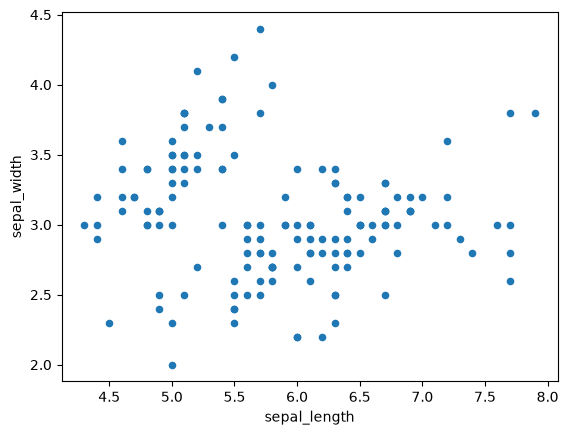

In [5]:
# plt.style.use("dark_background")
iris.plot(kind='scatter', x='sepal_length', y='sepal_width')
plt.show()

Cannot make much sense out it. 
 
What if we color the points by thier class-label/flower-type.

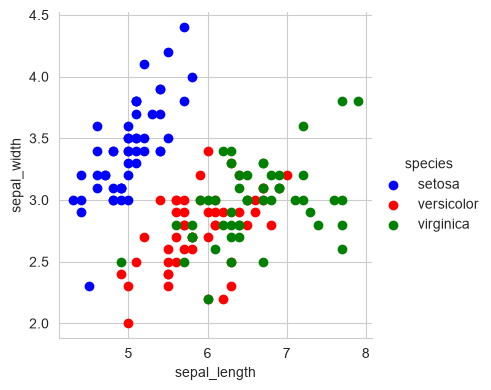

In [6]:
# 2D Scatter plot with color-coding for each flower type/class/species
sns.set_style("whitegrid")
g = (
    sns.FacetGrid(
        iris,
        hue="species",
        height=4,
        palette={"setosa": "blue", "versicolor": "red", "virginica": "green"},
    )
    .map(plt.scatter, "sepal_length", "sepal_width")
    .add_legend()
)

plt.show()

**Observations:**

1. Using the `sepal_length` and `sepal_width` features, we can distinguish **Setosa** flowers from the other species.

2. Separating **Versicolor** from **Virginica** is much harder because their data points have considerable overlap.


**Notice:**  

🔵 The **blue points (Setosa)** can be easily separated from the **red (Versicolor)** and **green (Virginica)** points by drawing a line.

🔴🟢 However, the **red and green points cannot be easily separated** using only `sepal_length` and `sepal_width`.

❓ Can we draw multiple **2-D scatter plots** using different combinations of features❓ 

🌸 The Iris dataset has **4 features**:
  - `sepal_length`
  - `sepal_width`
  - `petal_length`
  - `petal_width`

🔢 We need to choose **2 features at a time** from these 4 features.

The number of possible combinations is:
  **⁴C₂ = 6**

Therefore, we can create **6 different 2-D scatter plots** to find which pair of features separates the three species most effectively.


#### 3D Scatter Plot

https://plot.ly/pandas/3d-scatter-plots/

Needs a lot to mouse interaction to interpret data.

What about 4-D, 5-D or n-D scatter plot?

#### 3. Pair-plot

Pairwise Scatter Plot: Pair Plot

**Disadvantages:**

* ❌ Not suitable when the number of features is very high.
* ❌ Only shows **2D relationships** between feature pairs.
* ❌ Cannot visualize **3D, 4D, or higher-dimensional patterns** directly.


Only possible to view 2D patterns.

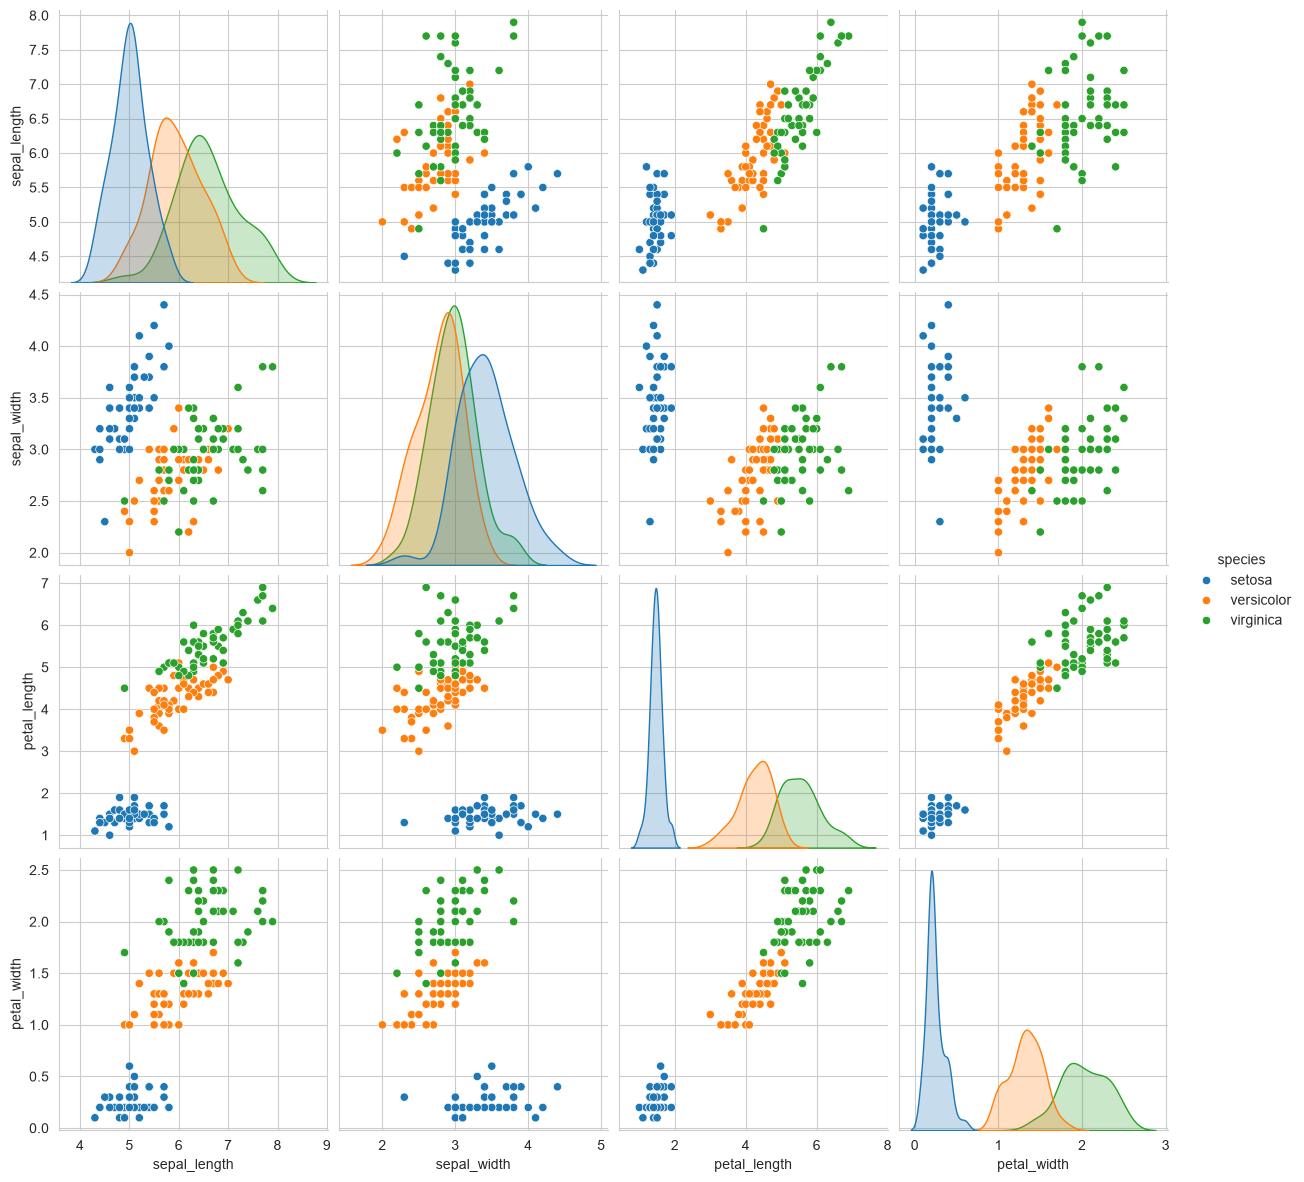

In [7]:
plt.close()
sns.set_style('whitegrid')
sns.pairplot(iris, hue='species', height=3)
plt.show()

# NOTE: the diagnol elements are PDFs for each feature. PDFs are expalined below.

NOTE: the diagnol elements are PDFs for each feature. PDFs are expalined below.

**Observations**

1. `petal_length` and `petal_width` are the most useful features for identifying flower types.

2. **Setosa** can be easily identified (linearly separable), while **Versicolor** and **Virginica** have some overlap (almost linearly separable).

3. We can use **lines** and **if-else conditions** to build a simple model for classifying flower types.


#### 4. [Histogram](./hist-pdf-cdf.md#histogram), [PDF](./hist-pdf-cdf.md#pdf), [CDF](./hist-pdf-cdf.md#cdf)

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = pd.read_csv('./Materials/Iris.csv')
# iris

In [9]:
iris_setosa = iris.loc[iris['species'] == 'setosa']
iris_versicolor = iris.loc[iris['species'] == 'versicolor']
iris_virginica = iris.loc[iris['species'] == 'virginica']

In [10]:
# iris_setosa

In [11]:
# iris_versicolor

In [12]:
# iris_virginica

What about 1D scatter plot using just one feature?   
> 1D scatter plot of `petal-length`

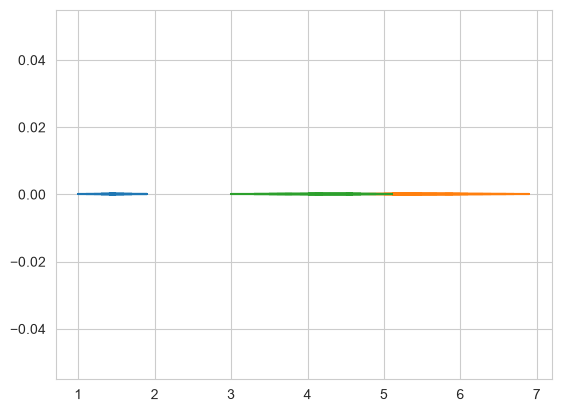

In [13]:
plt.plot(iris_setosa['petal_length'], np.zeros_like(iris_setosa['petal_length']))
plt.plot(iris_virginica['petal_length'], np.zeros_like(iris_virginica['petal_length']))
plt.plot(iris_versicolor['petal_length'], np.zeros_like(iris_versicolor['petal_length']))
plt.show()

Disadvantages of 1-D Scatter Plot

* ❌ Very hard to make sense of the data points.
* ❌ Points overlap heavily, making the distribution difficult to visualize.

> Are there better ways of visualizing 1-D scatter plots?


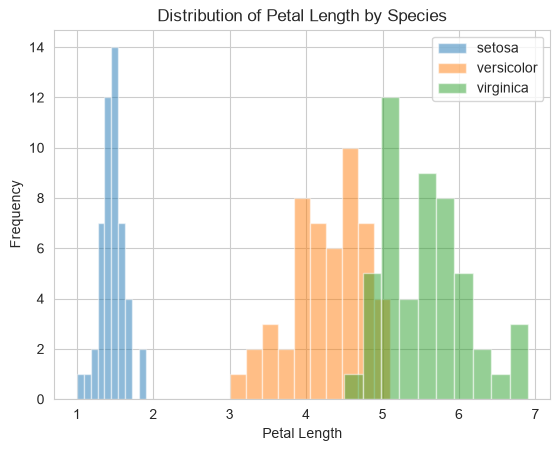

In [14]:
# Histograms of petal length for each species

plt.hist(
    iris_setosa['petal_length'],
    bins=10,
    alpha=0.5,
    label='setosa'
)

plt.hist(
    iris_versicolor['petal_length'],
    bins=10,
    alpha=0.5,
    label='versicolor'
)

plt.hist(
    iris_virginica['petal_length'],
    bins=10,
    alpha=0.5,
    label='virginica'
)

plt.xlabel('Petal Length')
plt.ylabel('Frequency')
plt.title('Distribution of Petal Length by Species')
plt.legend()

plt.show()

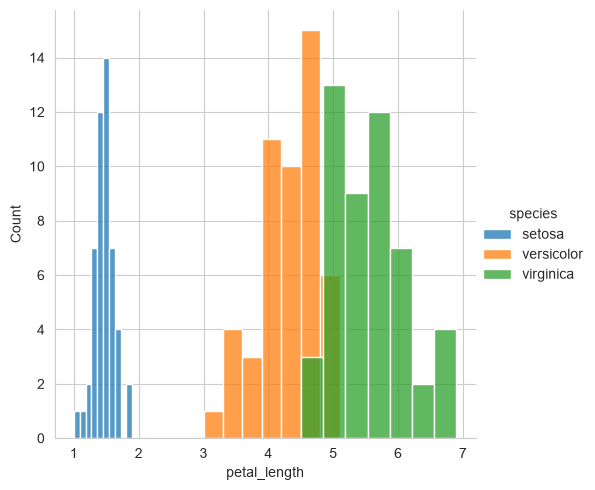

In [15]:
sns.FacetGrid(iris, hue="species", height=5).map(
    sns.histplot, "petal_length"
).add_legend()
plt.show()

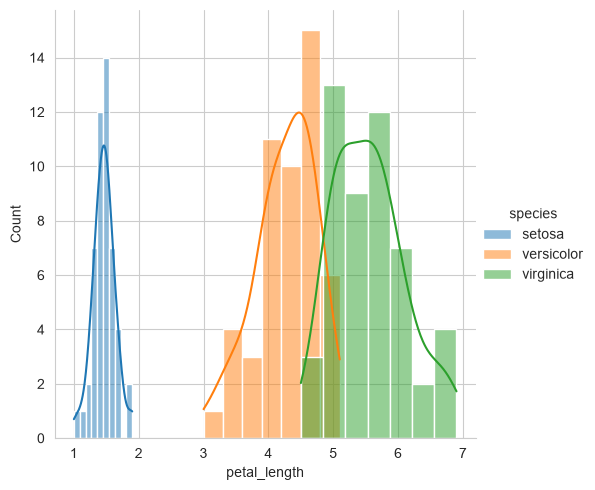

In [16]:
sns.FacetGrid(iris, hue="species", height=5).map(
    sns.histplot, "petal_length", kde=True
).add_legend()
plt.show()

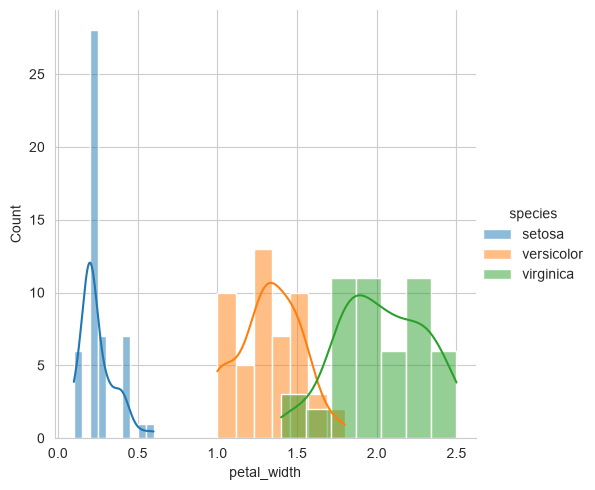

In [17]:
sns.FacetGrid(iris, hue="species", height=5).map(
    sns.histplot, "petal_width", kde=True
).add_legend()

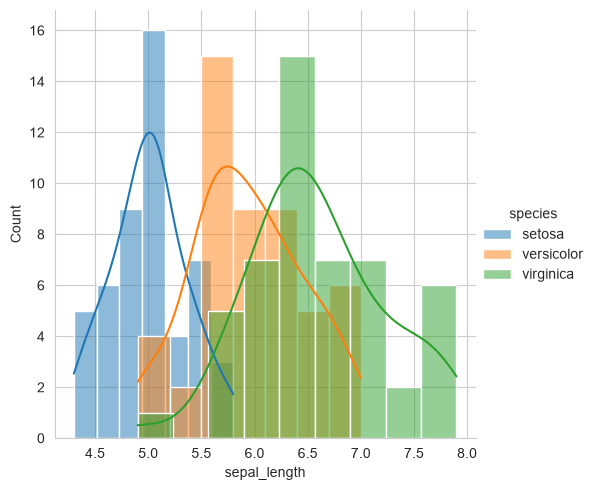

In [18]:
sns.FacetGrid(iris, hue="species", height=5).map(
    sns.histplot, "sepal_length", kde=True
).add_legend()

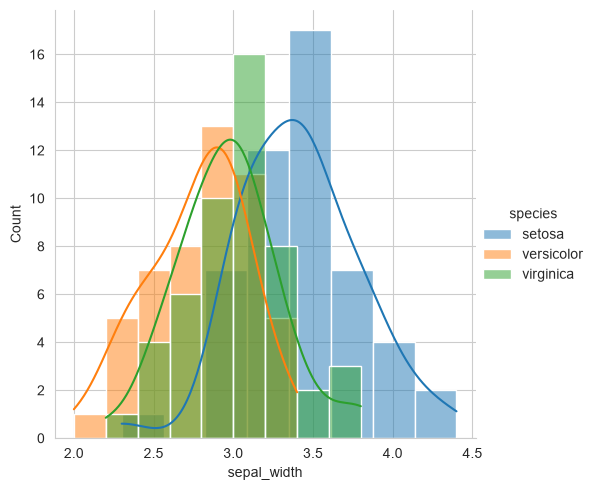

In [19]:
sns.FacetGrid(iris, hue="species", height=5).map(
    sns.histplot, "sepal_width", kde=True
).add_legend()

**Histograms and Probability Density Functions (PDF) using KDE**
* How to compute PDFs using the **counts/frequencies** of data points in each window.
* How **window width** affects the PDF plot.

Interpreting a PDF

* Why is it called a **density plot**?
* Why is it called a **probability plot**?
* For each value of `petal_length`, what does the value on the **y-axis** mean?

> Notice that we can write a simple **if-else condition**:
> `if (petal_length < 2.5)`, then the flower type is **Setosa**.

* Using just one feature, we can build a simple **"model"** using `if-else` statements.

Disadvantage of PDF

> Can we say what percentage of **Versicolor** points have a `petal_length` of less than 5?

Gaussian / Normal Distribution

* Do some of these plots look like a **bell curve** you studied in undergrad?
* **Gaussian / Normal Distribution**
* What is **"normal"** about the normal distribution?
* Example: **Heights of male students in a class.**
* One of the most frequently occurring distributions in nature.


In [20]:
# bin_edges[1:].shape,pdf.shape

Need for Cumulative Distribution Function (CDF)

* What percentage of **which flower** has a `petal_length` of less than 5?
* How to construct a **CDF**?
* How to read a **CDF**?


[0.02 0.02 0.04 0.14 0.24 0.28 0.14 0.08 0.   0.04]
[1.   1.09 1.18 1.27 1.36 1.45 1.54 1.63 1.72 1.81 1.9 ]


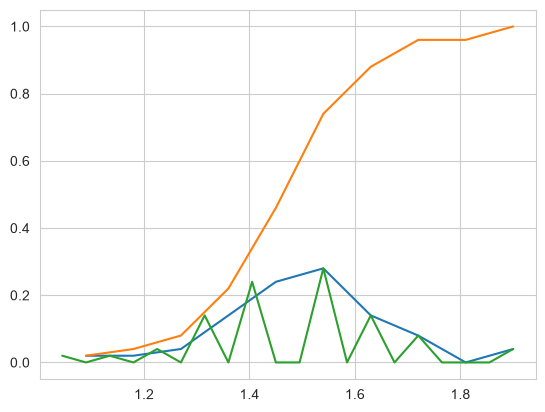

In [21]:
# CDF of petal_length

counts, bin_edges = np.histogram(iris_setosa["petal_length"], bins=10, density=True)

pdf = counts / (sum(counts))
print(pdf)
print(bin_edges)

# compute CDF
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:], pdf)
plt.plot(bin_edges[1:], cdf)

counts, bin_edges = np.histogram(iris_setosa["petal_length"], bins=20, density=True)
pdf = counts / (sum(counts))
plt.plot(bin_edges[1:], pdf)

plt.show()

Need for Cumulative Distribution Function (CDF)

* What **%** of **Versicolor** flowers have a `petal_length` < **1.6**.

* How to Construct a CDF?

* How to Read a CDF?


[0.02 0.02 0.04 0.14 0.24 0.28 0.14 0.08 0.   0.04]
[1.   1.09 1.18 1.27 1.36 1.45 1.54 1.63 1.72 1.81 1.9 ]


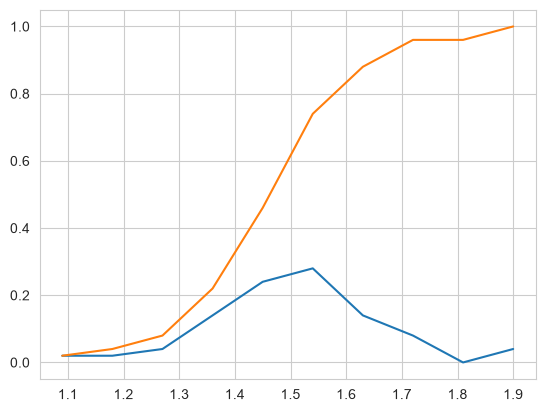

In [22]:
#Plot CDF of petal_length

counts, bin_edges = np.histogram(iris_setosa['petal_length'], bins=10, 
                                 density = True)
pdf = counts/(sum(counts))
print(pdf);
print(bin_edges)

#compute CDF
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:], cdf)



plt.show();

Plots of **CDF** of `petal_length` for various types of flowers.

Misclassification error if you use `petal_length` only.

[0.02 0.02 0.04 0.14 0.24 0.28 0.14 0.08 0.   0.04]
[1.   1.09 1.18 1.27 1.36 1.45 1.54 1.63 1.72 1.81 1.9 ]
[0.02 0.1  0.24 0.08 0.18 0.16 0.1  0.04 0.02 0.06]
[4.5  4.74 4.98 5.22 5.46 5.7  5.94 6.18 6.42 6.66 6.9 ]
[0.02 0.04 0.06 0.04 0.16 0.14 0.12 0.2  0.14 0.08]
[3.   3.21 3.42 3.63 3.84 4.05 4.26 4.47 4.68 4.89 5.1 ]


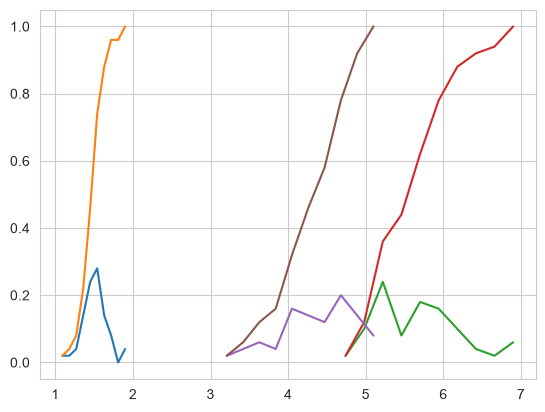

In [23]:
# CDF
# Setosa Petal Length
counts, bin_edges = np.histogram(iris_setosa['petal_length'], bins=10, density=True)
pdf = counts/(sum(counts))
print(pdf)
print(bin_edges)
# compute CDF
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:], pdf)
plt.plot(bin_edges[1:], cdf)

# Virginica Petal Length
counts, bin_edges = np.histogram(iris_virginica['petal_length'], bins=10, density=True)
pdf = counts/(sum(counts))
print(pdf)
print(bin_edges)
# compute CDF
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:], pdf)
plt.plot(bin_edges[1:], cdf)

# Versicolor Petal Length
counts, bin_edges = np.histogram(iris_versicolor['petal_length'], bins=10, density=True)
pdf = counts/(sum(counts))
print(pdf)
print(bin_edges)
# compute CDF
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:], pdf)
plt.plot(bin_edges[1:], cdf)

plt.show()

#### 5. Mean, Variance and Std-dev

In [24]:
# Mean, Variance, Std-deviation,
print("Means:")
print(np.mean(iris_setosa["petal_length"]))
print(np.mean(np.append(iris_setosa["petal_length"], 50)))  # Mean with an outlier.
print(np.mean(iris_versicolor["petal_length"]))
print(np.mean(iris_virginica["petal_length"]))

print("\nStd-dev:")
print(np.std(iris_setosa["petal_length"]))
print(np.std(iris_versicolor["petal_length"]))
print(np.std(iris_virginica["petal_length"]))

print("\nMeans & Std-dev:")
print(f"Mean: {np.mean(iris_setosa["petal_length"])}  Std-dev: {np.std(iris_setosa["petal_length"])}")
print(f"Mean: {np.mean(iris_versicolor["petal_length"])}  Std-dev: {np.std(iris_virginica["petal_length"])}")
print(f"Mean: {np.mean(iris_virginica["petal_length"])}  Std-dev: {np.std(iris_versicolor["petal_length"])}")

Means:
1.464
2.4156862745098038
4.26
5.5520000000000005

Std-dev:
0.17176728442867112
0.4651881339845203
0.546347874526844

Means & Std-dev:
Mean: 1.464  Std-dev: 0.17176728442867112
Mean: 4.26  Std-dev: 0.546347874526844
Mean: 5.5520000000000005  Std-dev: 0.4651881339845203


#### 6. Median, Percentile, Quantile, IQR, MAD

In [50]:
# Median, Quantiles, Percentiles, IQR.
print("\nMedians:")
print(np.median(iris_setosa["petal_length"]))
print(np.median(np.append(iris_setosa["petal_length"], 50)))  # Median with an outlier
print(np.median(iris_versicolor["petal_length"]))
print(np.median(iris_virginica["petal_length"]))

print("\nMode")
print(iris_setosa["petal_length"].mode().iloc[0])
print(iris_versicolor["petal_length"].mode().iloc[0])
print(iris_virginica["petal_length"].mode().iloc[0])

# from statistics import mode
# print("\nMode")
# print(mode(iris_setosa["petal_length"]))
# print(mode(iris_versicolor["petal_length"]))
# print(mode(iris_virginica["petal_length"]))

# print("\nQuantiles:")
# percentiles = np.arange(0, 1.01, 0.25)     #[0, 0.25, 0.50, 0.75, 1.00]
# print(np.quantile(iris_setosa["petal_length"], percentiles))
# print(np.quantile(iris_versicolor["petal_length"], percentiles))
# print(np.quantile(iris_virginica["petal_length"], percentiles))

print("\nPercentile:")
percentiles = np.arange(0, 101, 25)     #[0, 25, 50, 75, 100]
print(np.percentile(iris_setosa["petal_length"], percentiles))
print(np.percentile(iris_versicolor["petal_length"], percentiles))
print(np.percentile(iris_virginica["petal_length"], percentiles))

# percentile_table = pd.DataFrame(
#     [
#         np.percentile(iris_setosa["petal_length"], percentiles),
#         np.percentile(iris_versicolor["petal_length"], percentiles),
#         np.percentile(iris_virginica["petal_length"], percentiles),
#     ],
#     columns=["0%", "25%", "50%", "75%", "100%"],
# )
# percentile_table.index = ["Setosa", "Versicolor", "Virginica"]
# print("\nQuantiles:")
# print(percentile_table)

print("\n90th Percentiles:")
print(np.percentile(iris_setosa["petal_length"], 90))
print(np.percentile(iris_versicolor["petal_length"], 90))
print(np.percentile(iris_virginica["petal_length"], 90))

from statsmodels import robust

print("\nMedian Absolute Deviation")
print(robust.mad(iris_setosa["petal_length"]))
print(robust.mad(iris_versicolor["petal_length"]))
print(robust.mad(iris_virginica["petal_length"]))


Medians:
1.5
1.5
4.35
5.55

Mode
1.5
4.5
5.1

Percentile:
[1.    1.4   1.5   1.575 1.9  ]
[3.   4.   4.35 4.6  5.1 ]
[4.5   5.1   5.55  5.875 6.9  ]

90th Percentiles:
1.7
4.8
6.31

Median Absolute Deviation
0.14826022185056031
0.5189107764769602
0.6671709983275211


| Concept | Percentile | Quantile |
| ------- | ---------: | -------: |
| Minimum |         0% |     0.00 |
| Q1      |        25% |     0.25 |
| Median  |        50% |     0.50 |
| Q3      |        75% |     0.75 |
| Maximum |       100% |     1.00 |


#### 7. Box plot and Whiskers

Another method of visualizing the **1D** scatter plot more intuitivey.  
The Concept of `median`, `percentile`, `quantile`.  

- How to draw the box in the box-plot?  
- How to draw whiskers? 
> [no standard way] Could use `min` and `max` or use `other` complex statistical techniques.  

`IQR` like idea.  

**NOTE**: IN the plot below,   
- a technique called `inter-quartile range` is used in plotting the whiskers.   
- Whiskers in the plot below do not correposnd to the min and max values.  

> Box-plot can be visualized as a PDF on the side-ways.  

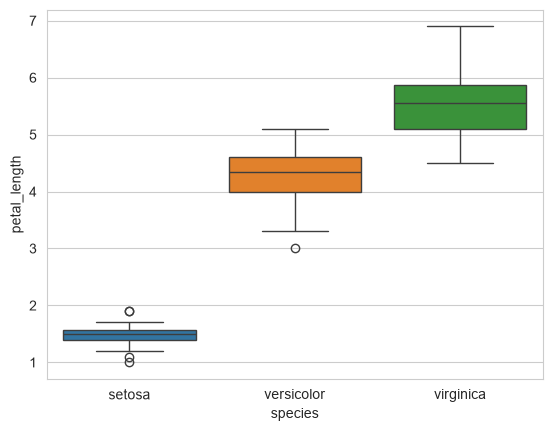

In [53]:
sns.boxplot(x="species", y="petal_length", hue='species', data=iris)
plt.show()

#### 8. Violin plots

A `violin` plot combines the benefits of the previous `histogram` and `box` plots and simplifies them

Denser regions of the data are fatter and sparser ones thinner in a violin plot

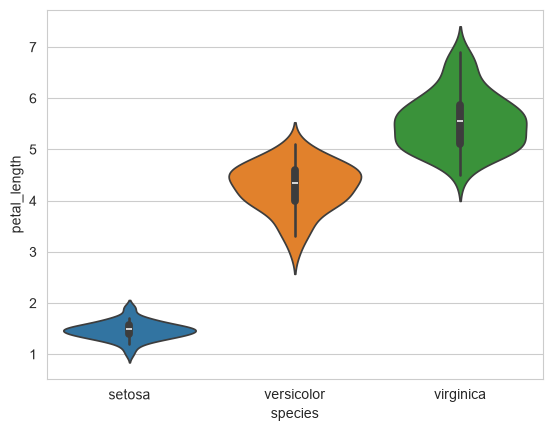

In [54]:
sns.violinplot(x="species", y="petal_length", hue='species', data=iris)
plt.show()

#### 9. Summarizing plots in english

* Exaplain your findings/conclusions in plain english
* Never forget your objective (the probelm you are solving) 
* Perform all of your EDA aligned with your objectives.
* **Observations**

#### 10. Univariate, bivariate and multivariate analysis.

In [55]:
# Def: Univariate, Bivariate and Multivariate analysis.

* **Univariate analysis:** Analysis of **one variable** at a time.
* **Bivariate analysis:** Analysis of the relationship between **two variables**.
* **Multivariate analysis:** Analysis involving **three or more variables**.


#### 11. Multivariate probability density, contour plot.

> 2D Density plot, contors-plot

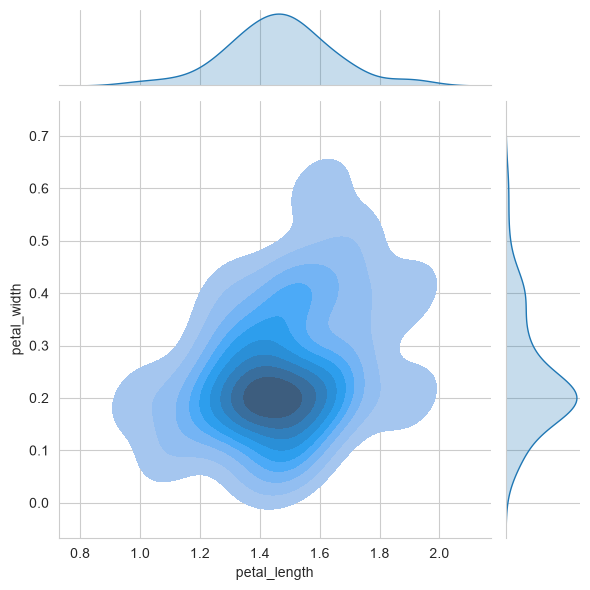

In [57]:
sns.jointplot(
    x="petal_length", y="petal_width", data=iris_setosa, kind="kde", fill=True
)
plt.show()

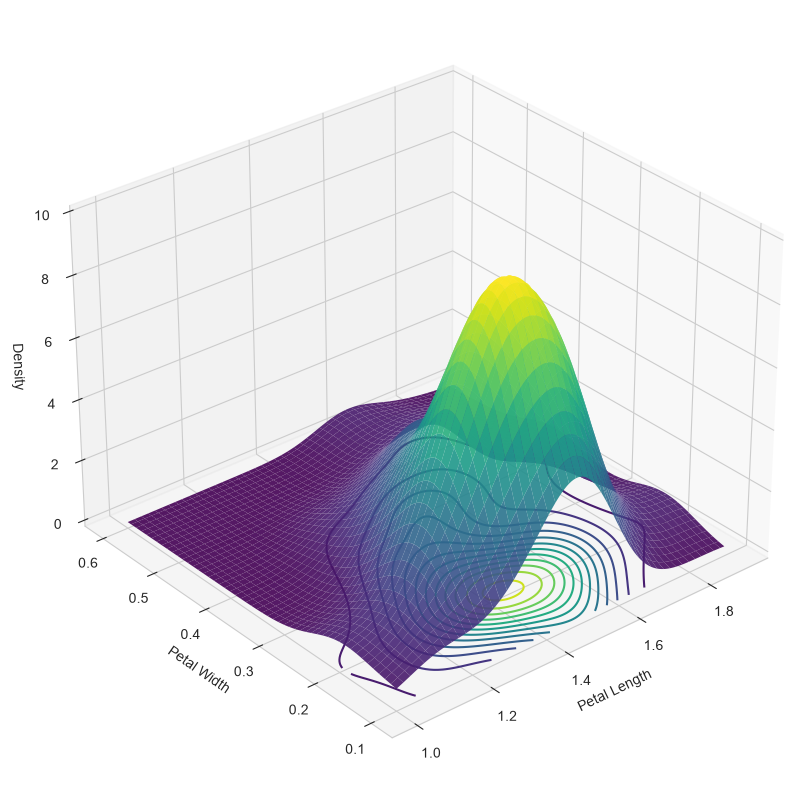

In [66]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np

x = iris_setosa["petal_length"].values
y = iris_setosa["petal_width"].values

kde = gaussian_kde(np.vstack([x, y]))

X, Y = np.meshgrid(
    np.linspace(x.min(), x.max(), 150),
    np.linspace(y.min(), y.max(), 150)
)

Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X, Y, Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.9
)

ax.contour(
    X, Y, Z,
    levels=15,
    zdir="z",
    offset=Z.min(),
    cmap="viridis"
)

ax.set_xlabel("Petal Length")
ax.set_ylabel("Petal Width")
ax.set_zlabel("Density")

ax.view_init(elev=30, azim=-130)

plt.tight_layout()
plt.show()

#### 12. Exercise:

1. Download Haberman Cancer Survival dataset from Kaggle. You may have to create a Kaggle account to donwload data. (https://www.kaggle.com/gilsousa/habermans-survival-data-set)
2. Perform a similar analysis as above on this dataset with the following sections:
* High level statistics of the dataset: number of points, numer of   features, number of classes, data-points per class.
* Explain our objective. 
* Perform Univaraite analysis(PDF, CDF, Boxplot, Voilin plots) to understand which features are useful towards classification.
* Perform Bi-variate analysis (scatter plots, pair-plots) to see if combinations of features are useful in classfication.
* Write your observations in english as crisply and unambigously as possible. Always quantify your results.